import libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

generate column orders_date

In [ ]:
np.random.seed(42)
n_orders = 1000
dates = pd.date_range(start="2025-01-01", periods=n_orders, freq="D")
orders = pd.DataFrame({
    "order_id": range(1, n_orders+1),
    "order_date": dates,
    "weight_kg": np.random.uniform(0.5, 20, n_orders),     
    "distance_km": np.random.uniform(1, 500, n_orders),     
    "total_spend": np.random.uniform(200, 5000, n_orders),  
    "total_orders": np.random.randint(1, 50, n_orders),     
    "signup_date": pd.to_datetime("2024-01-01") + pd.to_timedelta(
        np.random.randint(0, 365, n_orders), unit="D"
    )
})
orders["shipping_cost"] = (
    50 + 2.5*orders["weight_kg"] + 0.8*orders["distance_km"] +
    np.random.normal(0, 20, n_orders)  # noise
)
orders.to_csv("orders_features.csv", index=False)
print("column added")
print(orders.head())

column added
   order_id order_date  weight_kg  distance_km  total_spend  total_orders  \
0         1 2025-01-01   7.803532    93.381331  1456.187282            37   
1         2 2025-01-02  19.038929   271.408573  1385.498236             8   
2         3 2025-01-03  14.773882   436.599972  4550.021987             7   
3         4 2025-01-04  12.173840   366.380218  1397.821759            14   
4         5 2025-01-05   3.542363   403.474013  1505.358685             3   

  signup_date  shipping_cost  
0  2024-09-27     145.259066  
1  2024-05-19     293.512079  
2  2024-08-24     421.874359  
3  2024-03-12     347.847090  
4  2024-06-03     401.191430  


Q1. Temporal-split the orders table (Week 2's feature script). Fit plain LinearRegression; report train and validation RMSE and diagnose over/underfitting.

In [ ]:
orders = pd.read_csv("orders_features.csv")
orders = orders.sort_values("order_date")
split_idx = int(len(orders) * 0.8)
train = orders.iloc[:split_idx]
valid = orders.iloc[split_idx:]
X_train = train.drop(columns=["shipping_cost"])
y_train = train["shipping_cost"]
X_valid = valid.drop(columns=["shipping_cost"])
y_valid = valid["shipping_cost"]
X_train = X_train.select_dtypes(include=["number"])
X_valid = X_valid.select_dtypes(include=["number"])
linear = LinearRegression()
linear.fit(X_train, y_train)
train_preds = linear.predict(X_train)
valid_preds = linear.predict(X_valid)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
print(f"train: {train_rmse:.2f}")
print(f"Validation: {valid_rmse:.2f}")

train: 20.23
Validation: 19.59


Q2. Sweep Ridge l over [0.01…100] with 5-fold CV; plot l vs RMSE and mark the sweet spot — you have just drawn your own bias-variance curve.


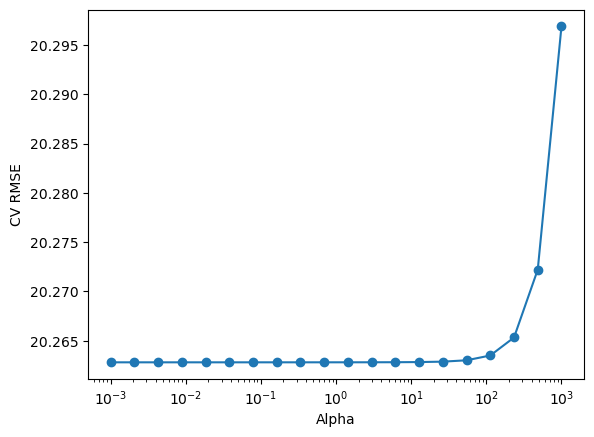

In [ ]:
X = orders.drop(columns=["shipping_cost"])
X = X.select_dtypes(include=["number"])
y = orders["shipping_cost"]
tscv = TimeSeriesSplit(n_splits=5)
lambdas = np.logspace(-3, 3, 20)
cv_scores = []
for l in lambdas:
    ridge = Ridge(alpha=l)
    scores = cross_val_score(ridge, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    cv_scores.append(-scores.mean())
plt.semilogx(lambdas, cv_scores, marker="o")
plt.xlabel("Alpha")
plt.ylabel("CV RMSE")
plt.show()

Q3. Fit Lasso with the chosen l and list which features were zeroed. Do the survivors match your Week 2 correlation intuition?

In [ ]:
lasso = Lasso(alpha=best_lambda)
lasso.fit(X_train, y_train)
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": lasso.coef_
})
zeroed = coef_df[coef_df["coef"] == 0]["feature"].tolist()
survivors = coef_df[coef_df["coef"] != 0]["feature"].tolist()
print("Zeroed features:", zeroed)
print("Survivors:", survivors)

Zeroed features: []
Survivors: ['order_id', 'weight_kg', 'distance_km', 'total_spend', 'total_orders']


create test_set

In [ ]:
orders = pd.read_csv("orders_features.csv")
orders = orders.sort_values("order_date")
split_idx = int(len(orders) * 0.8)
train_valid = orders.iloc[:split_idx]
sealed_test = orders.iloc[split_idx:]
sealed_test.to_csv("orders_test.csv", index=False)
print("test_set created")
print("rows:", len(sealed_test))


test_set created
rows: 200


Q4. Open the sealed test set ONCE. Report final RMSE and R² in one stakeholder sentence: 'Our quotes are typically within Rs. ___.'

In [ ]:
test = pd.read_csv("orders_test.csv")
X_test = test.drop(columns=["shipping_cost"])
y_test = test["shipping_cost"]
X_test = X_test.select_dtypes(include=["number"])
final_preds = lasso.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))
final_r2 = r2_score(y_test, final_preds)
print("RMSE:", final_rmse)
print("R²:", final_r2)

RMSE: 19.58813295581725
R²: 0.9705895744481192
